In [ ]:
!pip install netCDF4
!apt-get install libgeos-3.5.0
!apt-get install libgeos-dev
!pip install https://github.com/matplotlib/basemap/archive/master.zip
!pip install pyproj==1.9.6

Reading package lists... Done
Building dependency tree       
Reading state information... Done
E: Unable to locate package libgeos-3.5.0
E: Couldn't find any package by glob 'libgeos-3.5.0'
E: Couldn't find any package by regex 'libgeos-3.5.0'
Reading package lists... Done
Building dependency tree       
Reading state information... Done
libgeos-dev is already the newest version (3.6.2-1build2).
0 upgraded, 0 newly installed, 0 to remove and 40 not upgraded.
  Using cached https://github.com/matplotlib/basemap/archive/master.zip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

from datetime import datetime, timedelta

from netCDF4 import Dataset
from google.colab import drive, files

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model

tf.test.gpu_device_name()
print(tf.__version__)

2.6.0


In [ ]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Global constants
T0 = 273.15

In [ ]:
# Station for which to train the model
STATION_ID = '11190' # Eisenstadt
# STATION_ID = '11144' # Zell am See
STATION_ID = '11105' # Bregenz

# STATION_ID = '11389'
# STATION_ID = '11325'
# STATION_ID = '11329'
# STATION_ID = '11070'


### Data importation

In [ ]:
# Model Data
temperature_data = Dataset('/content/gdrive/My Drive/Colab Notebooks/ViennaTemperatureFields.nc') 
pressure_data = Dataset('/content/gdrive/My Drive/Colab Notebooks/ViennaPressureFields.nc') 
wind_data = Dataset('/content/gdrive/My Drive/Colab Notebooks/ViennaWindFields.nc') 

geopotential_data = Dataset('/content/gdrive/My Drive/Colab Notebooks/ViennaGeopotential850950hPa.nc')
data_850hPa = Dataset('/content/gdrive/My Drive/Colab Notebooks/ViennaRelativeHumidityTemperature850hPa.nc') 
data_950hPa = Dataset('/content/gdrive/My Drive/Colab Notebooks/ViennaRelativeHumidityTemperature950hPa.nc')  

# Obs Data
obs_data = np.load('/content/gdrive/My Drive/Colab Notebooks/VamesDataCleaned.npy', allow_pickle=True) 

In [ ]:
# Get station no. associated with station ID:
STATION_NR = next(i for i, x in enumerate(obs_data.item().keys()) if x == STATION_ID)
print(STATION_NR)

11


In [ ]:
lat = temperature_data['latitude'][:-1:2]
lon = temperature_data['longitude'][:-1:2]

# Surface data
temperature_model = temperature_data['t2m'][:,:-1:2,:-1:2]-T0
dewpoint_model = temperature_data['d2m'][:,:-1:2,:-1:2]-T0
pressure_model = pressure_data['sp'][:,:-1:2,:-1:2]/10000
precipitation_model = pressure_data['tp'][:,:-1:2,:-1:2]*1000
wind_u = wind_data['u10'][:][:,:-1:2,:-1:2]
wind_v = wind_data['v10'][:][:,:-1:2,:-1:2]

# Boundary layer data
geopotential850_model = geopotential_data['z'][:,0,:-1:2,:-1:2]/15000
geopotential950_model = geopotential_data['z'][:,1,:-1:2,:-1:2]/5500

rh850_model = data_850hPa['r'][:,:-1:2,:-1:2]
temperature850_model = data_850hPa['t'][:,:-1:2,:-1:2]-T0

rh950_model = data_950hPa['r'][:,:-1:2,:-1:2]
temperature950_model = data_950hPa['t'][:,:-1:2,:-1:2]-T0

# Data was downloaded hourly from 2016/01/01 to 2020/12/31
model_time = np.arange(datetime(2016,1,1,0,0), datetime(2021,1,1,0,0), timedelta(hours=1))

In [ ]:
b, c = 18.678, 257.14

gamma = np.log(np.maximum(0, rh850_model)/100)+b*temperature850_model/(c+temperature850_model)
dewpoint850_model = c*gamma/(b-gamma)

gamma = np.log(np.maximum(0,rh950_model)/100)+b*temperature950_model/(c+temperature950_model)
dewpoint950_model = c*gamma/(b-gamma)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log
  


In [ ]:
model_data = np.stack((temperature_model, dewpoint_model,
                       wind_u, wind_v, pressure_model,
                      #  geopotential950_model, geopotential850_model,
                       temperature850_model, temperature950_model,
                       dewpoint850_model, dewpoint950_model,
                       ), axis=3).astype(np.float32)

In [ ]:
print(model_data.shape)

(43848, 24, 24, 9)


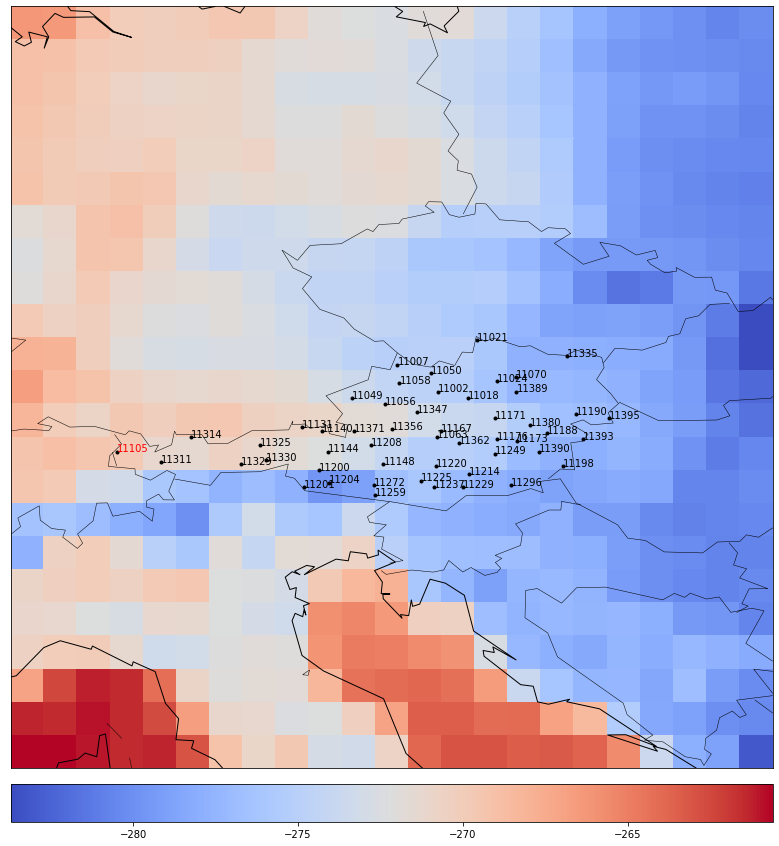

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
m = Basemap(projection='cyl',
                llcrnrlon=lon.min(),
                llcrnrlat=lat.min(), 
                urcrnrlon=lon.max(), 
                urcrnrlat=lat.max(), resolution='l')
m.pcolormesh(lon, lat, temperature_model[0,:,:]-T0, latlon=True, cmap=plt.cm.coolwarm)
m.colorbar(location='bottom')
m.drawcountries()
m.drawcoastlines(color='black')

for key in obs_data.item().keys():
  clat = obs_data.item().get(key)['lat'][0]
  clon = obs_data.item().get(key)['lon'][0]
  X, Y = m(clon, clat)
  m.plot(clon, clat,'k.')
  if key == STATION_ID:
    ax.annotate(key, (X,Y), color='r')
  else:
    ax.annotate(key, (X,Y))


In [ ]:
# Convert dictionary data into three-dimensional numpy array

# Select the temperature and wind data
data = []
for key in obs_data.item().keys():
  key = STATION_ID
  data.append(obs_data.item().get(key)[['VIS10','TL','TP','ff','dd']])

vames_data = np.array(data).astype(np.float32)
vames_data = np.transpose(vames_data, axes=(1,0,2))

# Select the time vector
vames_stamp = obs_data.item().get('11002')['time']

In [ ]:
print(vames_data.shape)
print(model_data.shape)

(263088, 51, 5)
(43848, 24, 24, 9)


In [ ]:
# Convert windspeed/direction to Cartesian components 
u, v = vames_data[:,:,3]*np.cos(2*np.pi*vames_data[:,:,4]/360), vames_data[:,:,3]*np.sin(2*np.pi*vames_data[:,:,4]/360) 
vames_data[:,:,3], vames_data[:,:,4] = u, v

In [ ]:
# # Normalize the data (for entire dataset, unfortunately, due to memory limitations)
obs_min = vames_data.min(axis=(0,1))
obs_max = vames_data.max(axis=(0,1))

model_min = model_data.min(axis=(0,1,2))
model_max = model_data.max(axis=(0,1,2))

model_data = (model_data - model_min)/(model_max - model_min)
vames_data = (vames_data - obs_min)/(obs_max - obs_min)

In [ ]:
# Use the past_history nr of data to predict future_target nr of data
past_history = 4
future_target = 2

In [ ]:
# Split into training data
TRAIN_SPLIT = np.int(0.8*len(model_data))
print(TRAIN_SPLIT)

35078


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Weights for each data sample
weights = [1,1,1,1,1,1,1,1]
# weights = [1,1,1,1,1,1,1,1]
# weights = [100,1000,100,100,10,10,1,1] # This worked reasonably well!

# Bins for computing the sample weights
bins = [-1, 150, 350, 600, 800, 1500, 3000, 5000, 100000]

# obs_data_cat = pd.cut(vames_data[:,STATION_NR, 0], bins, 
#                       labels=[0,1,2,3,4,5,6,7]).to_numpy()

# weights = compute_class_weight('balanced', [0,1,2,3,4,5,6,7], obs_data_cat)

In [ ]:
print(weights)

[1, 1, 1, 1, 1, 1, 1, 1]


### Data preparation

In [ ]:
def prepare_data(model_data, obs_data, station_nr, history_size, target_size):
  model = []
  obs = []
  labels = []
  sample_weight = []

  model_timesteps = len(model_data)
  obs_timesteps = len(obs_data)

  for i in range(history_size, model_timesteps-target_size):
    c_model = model_data[i-history_size:i+target_size,]
    c_obs = obs_data[6*(i-history_size):6*i,]

    # Parameter 0 is the visibility
    c_label = obs_data[6*i:6*(i+target_size),station_nr,0]

    # Sample weight
    c_weight = np.min(pd.cut(np.expand_dims(np.min(c_label), axis=0)*(obs_max[0]-obs_min[0]) + obs_min[0], 
                      bins, labels=[0,1,2,3,4,5,6,7]).to_numpy())
    c_weight = weights[c_weight]

    model.append(c_model); obs.append(c_obs); labels.append(c_label), sample_weight.append(c_weight)

  return np.array(model).astype(np.float16), np.array(obs).astype(np.float16), \
         np.array(labels).astype(np.float16), np.array(sample_weight).astype(np.uint8)

In [ ]:
x_model, x_obs, y_obs, sample_weight = prepare_data(model_data, vames_data, STATION_NR, 
                                                    past_history, future_target)

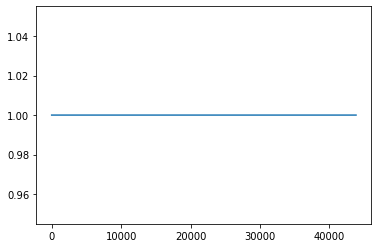

In [ ]:
plt.plot(sample_weight)

In [ ]:
# Split into training and testing data
x_model_train = x_model[:TRAIN_SPLIT]
x_model_test = x_model[TRAIN_SPLIT:]

x_obs_train = x_obs[:TRAIN_SPLIT]
x_obs_test = x_obs[TRAIN_SPLIT:]

y_obs_train = y_obs[:TRAIN_SPLIT]
y_obs_test = y_obs[TRAIN_SPLIT:]

sample_train = sample_weight[:TRAIN_SPLIT]

In [ ]:
# Total number of model features
nr_features_model = x_model_train.shape[-1]
nr_features_obs = x_obs_train.shape[-1]

# Nr of Vames stations
nr_stations = x_obs.shape[2]

# Lat and lon points
nr_lat, nr_lon = len(lat), len(lon)

In [ ]:
def slice(x, length):
  return x[:,STATION_NR, -length:,0]

def slice_feature(x, feature):
  return x[:,:,:,feature]

def obs_feature_block(x, feature):
  x = tf.keras.layers.Lambda(slice_feature, arguments={'feature': feature})(x)
  x = tf.keras.layers.BatchNormalization()(x)
  x = tf.keras.layers.LSTM(16, dropout=0.2)(x)
  return x

In [ ]:
x_obs.shape

(43842, 24, 51, 5)

In [ ]:
input_shape_obs = (6*past_history, nr_stations, nr_features_obs,)
input_shape_model = (past_history+future_target, nr_lon, nr_lat, nr_features_model,)

in_obs = tf.keras.layers.Input(shape=input_shape_obs)
in_model = tf.keras.layers.Input(shape=input_shape_model)

# Model branch: ConvLSTM network

in_last= tf.keras.layers.Lambda(slice, arguments={'length': 1})(in_obs)

b_model = tf.keras.layers.BatchNormalization()(in_model)
b_model = tf.keras.layers.ConvLSTM2D(8, kernel_size=(3,3), strides=(2,2), dropout=0.2,
                                     padding='same', return_sequences=True)(b_model)
b_model = tf.keras.layers.ConvLSTM2D(16, kernel_size=(3,3), strides=(2,2), dropout=0.2,
                                     padding='same', return_sequences=True)(b_model)
b_model = tf.keras.layers.ConvLSTM2D(32, kernel_size=(3,3), strides=(2,2), dropout=0.2,
                                     padding='same', return_sequences=True)(b_model)
# b_model = tf.keras.layers.ConvLSTM2D(32, kernel_size=(3,3), strides=(2,2),
#                                      padding='same', return_sequences=True)(b_model)
b_model = tf.keras.layers.ConvLSTM2D(64, kernel_size=(3,3), strides=(2,2),
                                     padding='same')(b_model)
b_model = tf.keras.layers.GlobalAveragePooling2D()(b_model)

# Observation branch: LSTM network

#  Separate LSTMs for the input features
b_obs_vis = obs_feature_block(in_obs, 0)
b_obs_T = obs_feature_block(in_obs, 1)
b_obs_Td = obs_feature_block(in_obs, 2)
b_obs_u = obs_feature_block(in_obs, 3)
b_obs_v = obs_feature_block(in_obs, 4)

b_obs = tf.keras.layers.Add()([b_obs_vis, b_obs_T, b_obs_Td,
                                       b_obs_u, b_obs_v])
b_obs = tf.keras.layers.Dense(64, 'tanh')(b_obs)

b = tf.keras.layers.Add()([b_obs, b_model])

out = tf.keras.layers.Dense(6*future_target, 'linear')(b)
out = tf.keras.layers.Add()([in_last, out])

model = tf.keras.models.Model([in_obs, in_model], out)
model.compile(optimizer='adam', loss='mse', metrics=['mse'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 6, 24, 24, 9 0                                            
__________________________________________________________________________________________________
input_1 (InputLayer)            [(None, 24, 51, 5)]  0                                            
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 6, 24, 24, 9) 36          input_2[0][0]                    
__________________________________________________________________________________________________
lambda_1 (Lambda)               (None, 24, 51)       0           input_1[0][0]                    
______________________________________________________________________________________________

In [ ]:
multi_step_history = model.fit([x_obs_train, x_model_train], y_obs_train, 
                               batch_size=64, epochs=6, sample_weight=sample_train)

Epoch 1/6
549/549 [==============================] - 117s 161ms/step - loss: 0.0449 - mse: 0.0449
Epoch 2/6
549/549 [==============================] - 87s 159ms/step - loss: 0.0333 - mse: 0.0333
Epoch 3/6
549/549 [==============================] - 87s 158ms/step - loss: 0.0312 - mse: 0.0312
Epoch 4/6
549/549 [==============================] - 86s 157ms/step - loss: 0.0302 - mse: 0.0302
Epoch 5/6
549/549 [==============================] - 86s 156ms/step - loss: 0.0292 - mse: 0.0292
Epoch 6/6
549/549 [==============================] - 86s 156ms/step - loss: 0.0284 - mse: 0.0284


In [ ]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

In [ ]:
x_obs_test.shape

(8764, 24, 51, 5)

In [ ]:
# plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

Text(0, 0.5, 'visibility [m]')

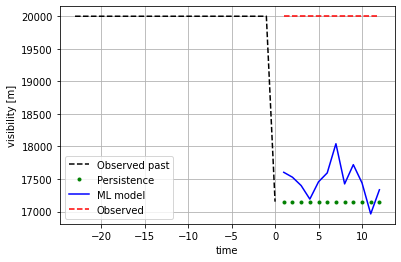

In [ ]:
# Plot some results
ix = np.random.randint(0, len(x_obs_test))

obs = np.expand_dims(x_obs_test[ix,:,STATION_NR,0], axis=0)*(obs_max[0]-obs_min[0]) + obs_min[0]
true_vis = np.expand_dims(y_obs_test[ix,], axis=0)*(obs_max[0]-obs_min[0]) + obs_min[0]

data_obs = np.expand_dims(x_obs_test[ix,], axis=0)
data_model = np.expand_dims(x_model_test[ix,:], axis=0)

vis_pred = model([data_obs, data_model])*(obs_max[0]-obs_min[0]) + obs_min[0]

# This is the input observations
plt.plot(np.arange(-6*past_history+1, 1), obs[0,:6*past_history],'k--')

# Persitence prediction
plt.plot(np.arange(1, 6*future_target+1), obs[0,-1]*np.ones(6*future_target),'g.')

# ML prediction
plt.plot(np.arange(1, 6*future_target+1), vis_pred[0,],'b')

# True observed future
plt.plot(np.arange(1, 6*future_target+1), true_vis[0,],'r--')

plt.legend(['Observed past','Persistence','ML model','Observed']) 
plt.grid()
plt.xlabel('time')
plt.ylabel('visibility [m]')

# for i in range(runs):
#  plt.plot(np.arange(0, future_target), np.round(vis_prob[i,0,]),'r-.')

In [ ]:
# Proper verification
from sklearn.metrics import *

In [ ]:
x_obs_test.shape

(8764, 24, 51, 5)

In [ ]:
# Now verify the model
# 1) Persistence error
y_pers = np.repeat(np.expand_dims(x_obs_test[:, past_history-1,STATION_NR,0], axis=1)*(obs_max[0]-obs_min[0]) + obs_min[0], 
                   6*future_target, axis=1)
y_pers = (y_pers-obs_min[0])/(obs_max[0]-obs_min[0]) 
err_pers = np.mean(np.square(y_pers - y_obs_test), axis=0)

# 2) ML model error
y_ml = model([x_obs_test, x_model_test]).numpy()
err_ml = np.mean(np.square(y_ml - y_obs_test), axis=0)

print('Persistence error: {}'.format(err_pers))
print('ML model error: {}'.format(err_ml))

Persistence error: [0.05338 0.05505 0.05576 0.05743 0.05667 0.0594  0.06015 0.06192 0.0635
 0.06476 0.0638  0.06635]
ML model error: [0.01491661 0.01865941 0.02273198 0.02592699 0.02662077 0.02914872
 0.03095672 0.03247905 0.03373145 0.03502931 0.03524932 0.03666249]


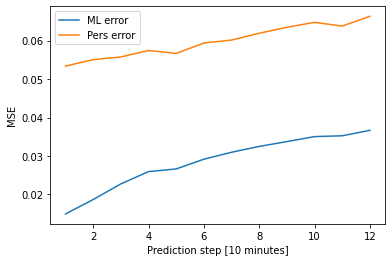

In [ ]:
plt.plot(np.arange(1,6*future_target+1,1), err_ml)
plt.plot(np.arange(1,6*future_target+1,1), err_pers)
plt.xlabel('Prediction step [10 minutes]')
plt.ylabel('MSE')
plt.legend(['ML error','Pers error'])

In [ ]:
# Convert to categorical for verification
y_pers_cat = 0*y_pers
y_ml_cat = 0*y_ml
y_true_cat = 0*y_obs_test

bins = [-10000, 150, 350, 600, 800, 1500, 3000, 5000, 100000]

for i in range(6*future_target):
  y_pers_cat[:,i] = pd.cut(y_pers[:,i]*(obs_max[0]-obs_min[0]) + obs_min[0], 
                           bins, labels=[0,1,2,3,4,5,6,7]).to_numpy()
  y_ml_cat[:,i] = pd.cut(y_ml[:,i]*(obs_max[0]-obs_min[0]) + obs_min[0], 
                         bins, labels=[0,1,2,3,4,5,6,7]).to_numpy()
  y_true_cat[:,i] = pd.cut(y_obs_test[:,i]*(obs_max[0]-obs_min[0]) + obs_min[0], 
                           bins, labels=[0,1,2,3,4,5,6,7]).to_numpy()

# Bin the data (second possibility)
# bins = [-1, 800, 1500, 3000, 5000, 8000, 10000]
# obs_data[:,0] = pd.cut(obs_data[:,0], bins, labels=[0,1,2,3,4,5]).to_numpy()

num_classes = len(bins)-1

In [ ]:
nr_classes = num_classes

precision_pers = np.zeros((nr_classes, 6*future_target))
recall_pers = np.zeros((nr_classes, 6*future_target))
f1_pers = np.zeros((nr_classes, 6*future_target))
balanced_acc_pers = np.zeros(6*future_target)

precision_ml = np.zeros((nr_classes,6*future_target))
recall_ml = np.zeros((nr_classes,6*future_target))
f1_ml = np.zeros((nr_classes,6*future_target))
balanced_acc_ml = np.zeros(6*future_target)

for i in range(6*future_target):
  precision_pers[:,i] = precision_score(y_true_cat[:,i], y_pers_cat[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)
  precision_ml[:,i] = precision_score(y_true_cat[:,i], y_ml_cat[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)

  recall_pers[:,i] = recall_score(y_true_cat[:,i], y_pers_cat[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)
  recall_ml[:,i] = recall_score(y_true_cat[:,i], y_ml_cat[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)

  f1_pers[:,i] = f1_score(y_true_cat[:,i], y_pers_cat[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)
  f1_ml[:,i] = f1_score(y_true_cat[:,i], y_ml_cat[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)
  
  balanced_acc_pers[i] = accuracy_score(y_true_cat[:,i], y_pers_cat[:,i])
  balanced_acc_ml[i] = accuracy_score(y_true_cat[:,i], y_ml_cat[:,i])

In [ ]:
def categorical_skill_scores(y_true, y_pred):

  # Compute the confusion matrix
  C = confusion_matrix(y_true, y_pred, labels=[i for i in range(num_classes)])
  C = C.transpose()
  nr_fcst = np.sum(C, axis=1)
  nr_obs = np.sum(C, axis=0)
  N = np.sum(nr_obs)

  # Heidke skill score
  HSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_fcst*nr_obs))

  # Peirce skill score
  PSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_obs**2))

  return HSS, PSS

In [ ]:
np.set_printoptions(precision=2)
for i in range(6*future_target):
  HSS, PSS = categorical_skill_scores(y_true_cat[:,i], y_ml_cat[:,i])
  print('Prediction minute {} (step {}):'.format(10*(i+1), i+1))
  print('Precision score ML: {}'.format(precision_ml[:,i]))
  print('Precision score PE: {}'.format(precision_pers[:,i]))
  print('Recall score ML: {}'.format(recall_ml[:,i]))
  print('Recall score PE: {}'.format(recall_pers[:,i]))
  print('Accuracy ML: {}'.format(np.round(100*balanced_acc_ml[i])/100.0))
  print('Accuracy PE: {}'.format(np.round(100*balanced_acc_pers[i])/100.0))
  print('Heidke skill score ML: {}\nPeirce skill score ML: {}'.format(HSS, PSS))
  HSS, PSS = categorical_skill_scores(y_true_cat[:,i],y_pers_cat[:,i])
  print('Heidke skill score PE: {}\nPeirce skill score PE: {}\n'.format(HSS, PSS))

Prediction minute 10 (step 1):
Precision score ML: [0.13 0.   0.14 0.12 0.07 0.18 0.37 0.97]
Precision score PE: [0.21 0.31 0.08 0.   0.16 0.14 0.21 0.96]
Recall score ML: [0.09 0.   0.02 0.06 0.07 0.21 0.35 0.99]
Recall score PE: [0.15 0.34 0.07 0.   0.16 0.18 0.2  0.96]
Accuracy ML: 0.92
Accuracy PE: 0.89
Heidke skill score ML: 0.47520989734465374
Peirce skill score ML: 0.43146630707014627
Heidke skill score PE: 0.36343261416328027
Peirce skill score PE: 0.36832515385799647

Prediction minute 20 (step 2):
Precision score ML: [0.13 0.2  0.13 0.   0.07 0.25 0.41 0.97]
Precision score PE: [0.21 0.3  0.08 0.06 0.19 0.18 0.18 0.96]
Recall score ML: [0.06 0.01 0.07 0.   0.06 0.25 0.4  0.99]
Recall score PE: [0.16 0.35 0.07 0.05 0.19 0.19 0.18 0.96]
Accuracy ML: 0.92
Accuracy PE: 0.89
Heidke skill score ML: 0.488972590951786
Peirce skill score ML: 0.44236194242755245
Heidke skill score PE: 0.35771902362084484
Peirce skill score PE: 0.3607079177956089

Prediction minute 30 (step 3):
Precisio

In [ ]:
for i in range(6*future_target):
  print('\n-----------------------------------------------------------')
  print('-----------------------------------------------------------\n')
  print('Classification summary ML model at forecast minute {}:\n'.format(10*(i+1)))
  print(classification_report(y_true_cat[:,i], y_ml_cat[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_true_cat[:,i], y_ml_cat[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('\n-----------------------------------------------------------\n')
  print('Classification summary Persistence at forecast minute {}:\n'.format(10*(i+1)))
  print(classification_report(y_true_cat[:,i], y_pers_cat[:,i], labels=[k for k in range(num_classes)]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_true_cat[:,i], y_pers_cat[:,i], labels=[k for k in range(num_classes)]))  
  print('\n')


-----------------------------------------------------------
-----------------------------------------------------------

Classification summary ML model at forecast minute 10:

              precision    recall  f1-score   support

           0       0.13      0.09      0.11        33
           1       0.00      0.00      0.00        99
           2       0.14      0.02      0.04        45
           3       0.12      0.06      0.08        18
           4       0.07      0.07      0.07        82
           5       0.18      0.21      0.19       177
           6       0.37      0.35      0.36       318
           7       0.97      0.99      0.98      7992

    accuracy                           0.92      8764
   macro avg       0.25      0.22      0.23      8764
weighted avg       0.91      0.92      0.91      8764

Confusion matrix:

[[   3    0    0    0    8   18    4    0]
 [   1    0    1    1   41   39    8    8]
 [   2    0    1    1   13   20    2    6]
 [   0    0    0    1  

In [ ]:
model.save('SixHoursPast_OneHour_TTdUVP.h5')

/usr/local/lib/python3.7/dist-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)
